In [ ]:
#Take Home Assignment Testing data analysis skills with pandas, numpy, and matplotlib. Use the dataset "used_device_data.csv" from the zip file.
#Total points: 20

#You are allowed to seek help from your classmates; however, it should be your own work.
#You can not copy or paste their work. If you seek help, you need to acknowledge it in your submission.
#You will submit the commented and outputs-printed Jupyter Notebook file

#Remove all unnecessary code and outputs.


In [1]:
#Importating Python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix #You may or may not need

In [2]:
df = pd.read_csv("used_device_data.csv")

In [3]:
#Question 1: Report any data limitations. Your response must be generated using Python code; do not calculate or analyze this manually. (2 points)

# This is a quick check of the non-null count and Dtype of each column.
df.info()

# This adds the number of null values, divides them by the total # of rows, and multiplies them by 100 to get a percentage.
# The highest percentage of null values is roughly 5.18%.
# Depending on the analysis we are performing, this helps us decide how the missing values should be handled.
# Null values are a data limitation.
df.isnull().sum() / df.shape[0] * 100

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3454 entries, 0 to 3453
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   device_brand           3454 non-null   object 
 1   os                     3454 non-null   object 
 2   screen_size            3454 non-null   float64
 3   4g                     3454 non-null   object 
 4   5g                     3454 non-null   object 
 5   rear_camera_mp         3275 non-null   float64
 6   front_camera_mp        3452 non-null   float64
 7   internal_memory        3450 non-null   float64
 8   ram                    3450 non-null   float64
 9   battery                3448 non-null   float64
 10  weight                 3447 non-null   float64
 11  release_year           3454 non-null   int64  
 12  days_used              3454 non-null   int64  
 13  normalized_used_price  3454 non-null   float64
 14  normalized_new_price   3454 non-null   float64
dtypes: f

device_brand             0.000000
os                       0.000000
screen_size              0.000000
4g                       0.000000
5g                       0.000000
rear_camera_mp           5.182397
front_camera_mp          0.057904
internal_memory          0.115808
ram                      0.115808
battery                  0.173712
weight                   0.202664
release_year             0.000000
days_used                0.000000
normalized_used_price    0.000000
normalized_new_price     0.000000
dtype: float64

In [4]:
#I ran this to make sure there were no duplicated rows. There was 0 therefore this is not a limitation of this data set.
df.duplicated().sum()

np.int64(0)

In [5]:
#I ran this and used the metadata to see if any values were obviously unreasonable.
df.describe()

# Internal memory has a maximum of 1024 GB compared to a 75th percentile of 64 GB.
# This is an extreme value but is still possible, so I would not consider it invalid based on this information alone.

,screen_size,rear_camera_mp,front_camera_mp,internal_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
count,3454.000000,3275.000000,3452.000000,3450.000000,3450.000000,3448.000000,3447.000000,3454.000000,3454.000000,3454.000000,3454.000000
mean,13.713115,9.460208,6.554229,54.573099,4.036122,3133.402697,182.751871,2015.965258,674.869716,4.364712,5.233107
std,3.805280,4.815461,6.970372,84.972371,1.365105,1299.682844,88.413228,2.298455,248.580166,0.588914,0.683637
min,5.080000,0.080000,0.000000,0.010000,0.020000,500.000000,69.000000,2013.000000,91.000000,1.536867,2.901422
25%,12.700000,5.000000,2.000000,16.000000,4.000000,2100.000000,142.000000,2014.000000,533.500000,4.033931,4.790342
50%,12.830000,8.000000,5.000000,32.000000,4.000000,3000.000000,160.000000,2015.500000,690.500000,4.405133,5.245892
75%,15.340000,13.000000,8.000000,64.000000,4.000000,4000.000000,185.000000,2018.000000,868.750000,4.755700,5.673718
max,30.710000,48.000000,32.000000,1024.000000,12.000000,9720.000000,855.000000,2020.000000,1094.000000,6.619433,7.847841


In [9]:
# I ran this to check the categorical columns for any imbalance or unusual values.
for col in ['device_brand', 'os', '4g', '5g']:
    print(col)
    print(df[col].value_counts(dropna=False))
    print()

device_brand
device_brand
Others        502
Samsung       341
Huawei        251
LG            201
Lenovo        171
ZTE           140
Xiaomi        132
Oppo          129
Asus          122
Alcatel       121
Micromax      117
Vivo          117
Honor         116
HTC           110
Nokia         106
Motorola      106
Sony           86
Meizu          62
Gionee         56
Acer           51
XOLO           49
Panasonic      47
Realme         41
Apple          39
Lava           36
Celkon         33
Spice          30
Karbonn        29
Coolpad        22
BlackBerry     22
Microsoft      22
OnePlus        22
Google         15
Infinix        10
Name: count, dtype: int64

os
os
Android    3214
Others      137
Windows      67
iOS          36
Name: count, dtype: int64

4g
4g
yes    2335
no     1119
Name: count, dtype: int64

5g
5g
no     3302
yes     152
Name: count, dtype: int64



The dataset contains 3,214 Android devices compared to only 36 iOS devices. This creates a limitation in the variety of operating systems represented in the dataset.

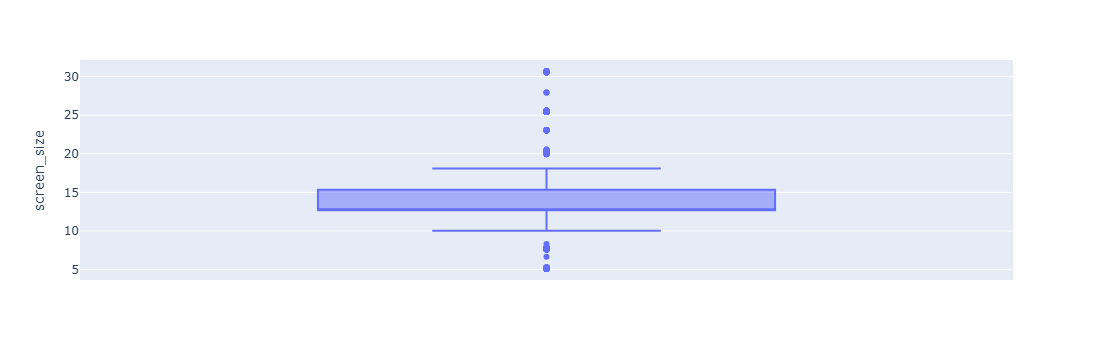

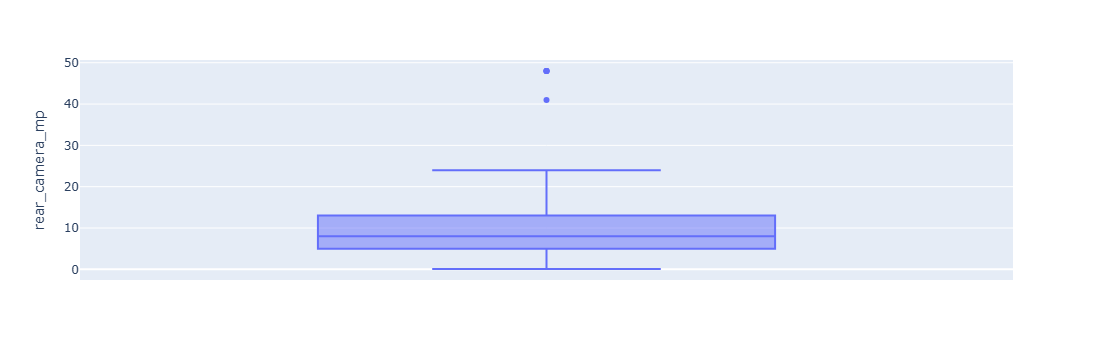

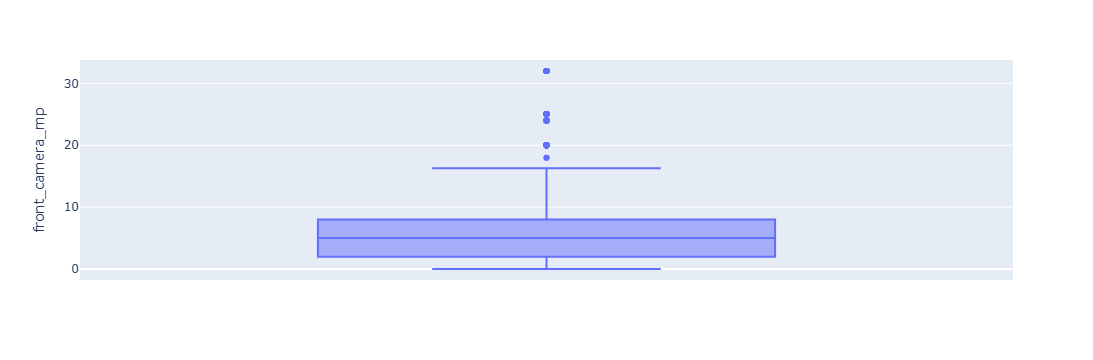

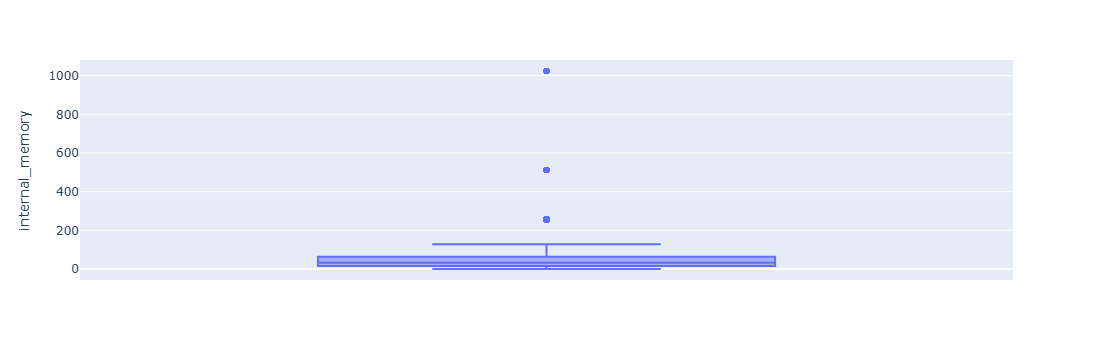

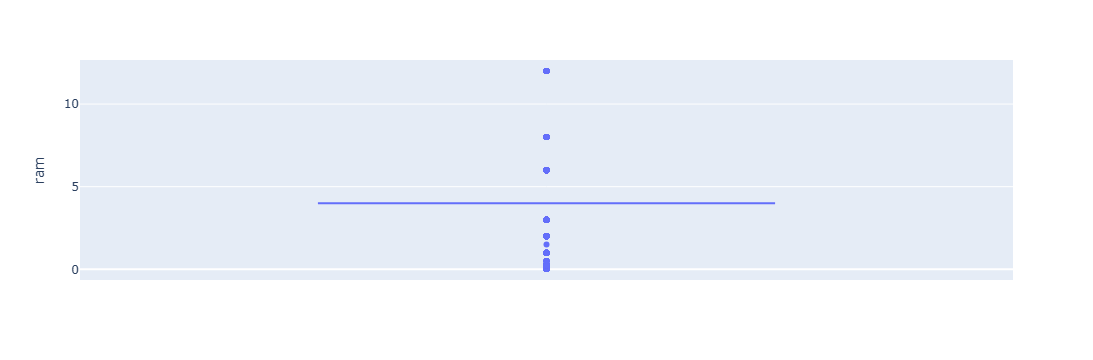

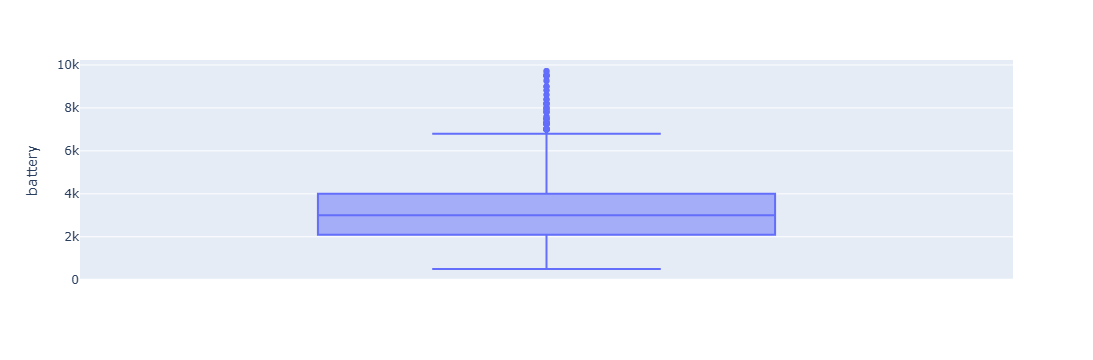

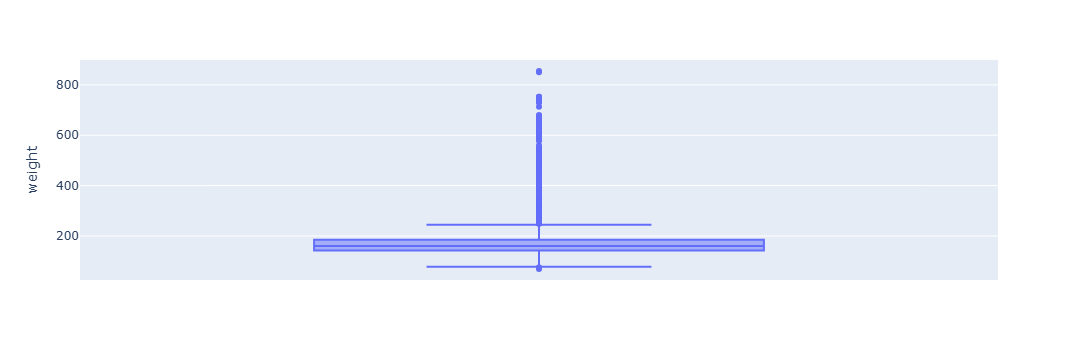

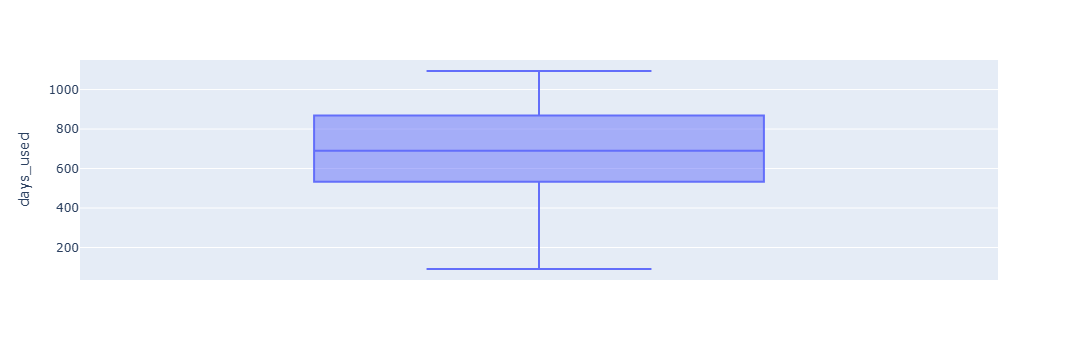

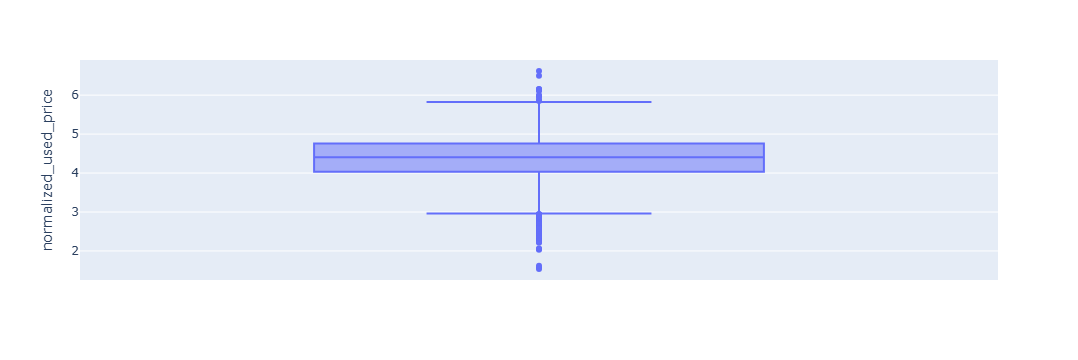

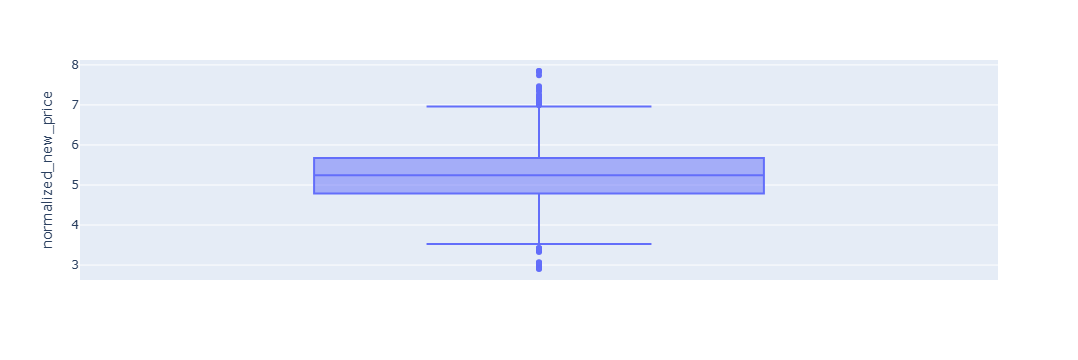

In [11]:
#Question 2: Use visualizations to identify and comment on outliers for every relevant column. (2 points)
# I selected the relevant numeric columns to check for outliers using boxplots.
import plotly.express as px

outlier_columns = [
    'screen_size',
    'rear_camera_mp',
    'front_camera_mp',
    'internal_memory',
    'ram',
    'battery',
    'weight',
    'days_used',
    'normalized_used_price',
    'normalized_new_price'
]

for column in outlier_columns:
    fig = px.box(df, y=column)
    fig.show()

Outlier Observations
- Screen size: Outliers are present on both the lower and upper ends.
- Rear camera MP: A small number of high outliers are present, including two much larger values around 40–48 MP.
- Front camera MP: Several high outliers are present above the upper whisker.
- Internal memory: A few large upper outliers are present, with the largest reaching 1024 GB.
- RAM: Outliers are present on both the lower and upper ends.
- Battery: Many upper outliers are present, extending to nearly 10,000 mAh.
- Weight: Many upper outliers are present, including some substantially higher than the main distribution.
- Days used: No outliers are identified by the boxplot.
- Normalized used price: Outliers are present on both the lower and upper ends.
- Normalized new price: Outliers are present on both the lower and upper ends.

In [16]:
#Question 3: Create a new column device_age that represents the age of the device in years. Print the mean and variance of device age. (1 point)
# I created device_age by subtracting each release year from the most recent release year in the dataset.
# I then calculated the mean and variance of device_age.

df['device_age'] = df['release_year'].max() - df['release_year']

print('Mean device age:', df['device_age'].mean())
print('Variance of device age:', df['device_age'].var())


Mean device age: 4.034742327735958
Variance of device age: 5.282893403032638


Correlation: 0.8344960187989928


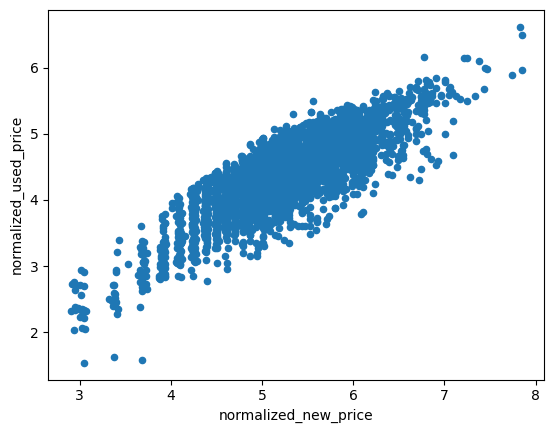

In [17]:
#Question 4: Comment on the pattern of the relationship between normalized_new_price and normalized_used_price. Use any appropriate statistical measure(one sentence). (2 points)
# I used a scatterplot and correlation to examine the relationship between new and used device prices.

df.plot.scatter(x='normalized_new_price', y='normalized_used_price')

correlation = df['normalized_new_price'].corr(df['normalized_used_price'])
print('Correlation:', correlation)



With a correlation of 0.834 and the scatterplot, there is a strong positive relationship between normalized new price and normalized used price.

In [18]:
#Question 5: Now, start using numpy functions to generate more numerical insights from the data
#Question 5a: Calculate the average, median, minimum, and maximum values of days_used and print them.  (2 points)

# I used NumPy functions to calculate the average, median, minimum, and maximum days used.

days_used = np.array(df['days_used'])

print('Average days used:', np.mean(days_used))
print('Median days used:', np.median(days_used))
print('Minimum days used:', np.min(days_used))
print('Maximum days used:', np.max(days_used))

Average days used: 674.8697162709901
Median days used: 690.5
Minimum days used: 91
Maximum days used: 1094


In [19]:
#Question 5b: Calculate and print the standard deviation and variance of normalized_used_price. (1 point)

# I used NumPy functions to calculate the standard deviation and variance of normalized used price.

used_price = np.array(df['normalized_used_price'])

print('Standard deviation:', np.std(used_price))
print('Variance:', np.var(used_price))

Standard deviation: 0.5888283607206609
Variance: 0.3467188383889808


In [20]:
#Question 5c: Calculate the 25th, 50th, and 75th percentiles of normalized_new_price and normalized_used_price. (1 point)

# I used NumPy to calculate the 25th, 50th, and 75th percentiles of normalized new and used prices.

new_price = np.array(df['normalized_new_price'])
used_price = np.array(df['normalized_used_price'])

print('New price percentiles:', np.percentile(new_price, [25, 50, 75]))
print('Used price percentiles:', np.percentile(used_price, [25, 50, 75]))

New price percentiles: [4.79034184 5.24589185 5.67371825]
Used price percentiles: [4.03393085 4.40513262 4.75570001]


In [21]:
#Question 5d: Count the number of devices in the data which have a normalized used price of less than 4.5. (1 point)

# I used NumPy to count the number of devices with a normalized used price below 4.5.

used_price = np.array(df['normalized_used_price'])

count_below_45 = np.sum(used_price < 4.5)

print('Number of devices with normalized used price below 4.5:', count_below_45)

Number of devices with normalized used price below 4.5: 2001


In [22]:
#Question 6: We often deal with massive datasets. In such cases, sampling is a useful approach. 
#Randomly sample 500 devices from the dataset and calculate the average normalized_used_price from that sample and print. (1 point)

# I randomly sampled 500 devices and calculated the average normalized used price of the sample.

sample_500 = df.sample(n=500)

average_sample_price = sample_500['normalized_used_price'].mean()

print('Average normalized used price of sample:', average_sample_price)

Average normalized used price of sample: 4.34997753952


In [23]:
#Question 7a: Calculate the z-scores of normalized_used_price to identify outliers. 
#You can use 3 standard deviations to identify outliers. 
#Print the number of outliers. (2 points)

# I calculated the z-scores of normalized used price and counted values more than 3 standard deviations from the mean.

used_price = np.array(df['normalized_used_price'])

mean_price = np.mean(used_price)
std_price = np.std(used_price)

z_scores = (used_price - mean_price) / std_price

outliers = np.sum(np.abs(z_scores) > 3)

print('Number of outliers:', outliers)

Number of outliers: 35


In [24]:
# Question 7b: Continuing from 7a, you are now interested to know why these are outliers. 
    #You think that days_used, internal_memory, and weight could be the reasons. 
#Compare these three variables of your outliers and the whole data and print them. Comment on your results.
#Hint: Create a separate dataframe (subset) for the outliers. (3 points)

# I created a subset of the outliers and compared their days_used, internal_memory, and weight
# to the same variables in the full dataset.

outlier_df = df[np.abs(z_scores) > 3]

variables = ['days_used', 'internal_memory', 'weight']

print('Outliers:')
print(outlier_df[variables].describe())

print('\nFull Dataset:')
print(df[variables].describe())


Outliers:
         days_used  internal_memory      weight
count    35.000000        33.000000   35.000000
mean    679.971429       177.489697  140.662857
std     229.167610       217.497052   79.761730
min     120.000000         0.060000   69.000000
25%     560.000000        16.000000   89.500000
50%     687.000000       128.000000  140.000000
75%     827.000000       256.000000  150.000000
max    1037.000000      1024.000000  468.000000

Full Dataset:
         days_used  internal_memory       weight
count  3454.000000      3450.000000  3447.000000
mean    674.869716        54.573099   182.751871
std     248.580166        84.972371    88.413228
min      91.000000         0.010000    69.000000
25%     533.500000        16.000000   142.000000
50%     690.500000        32.000000   160.000000
75%     868.750000        64.000000   185.000000
max    1094.000000      1024.000000   855.000000


The outliers have similar average days used compared to the full dataset (680 vs. 675), so days used does not appear to explain the outliers. The outliers have much higher average internal memory (177 GB vs. 55 GB) and lower average weight (141 g vs. 183 g). Internal memory and weight appear to be more associated with the unusually high normalized used prices.

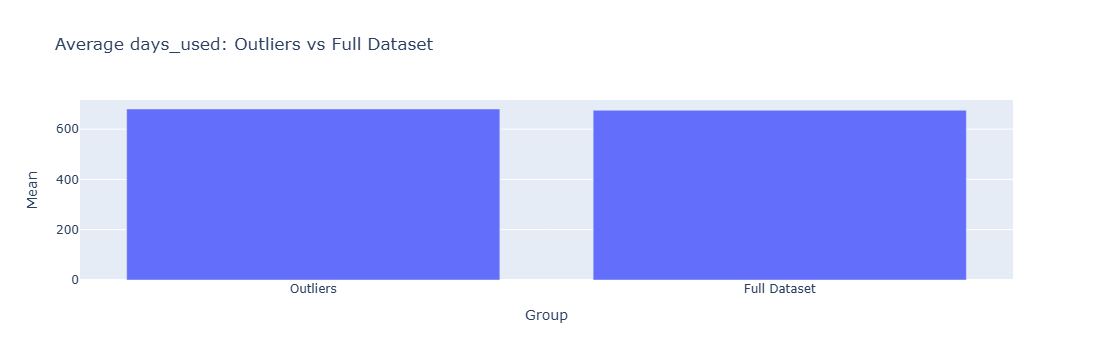

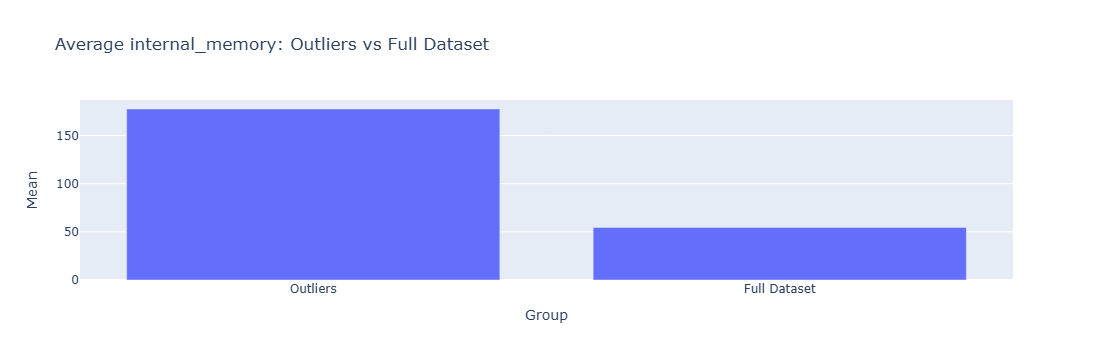

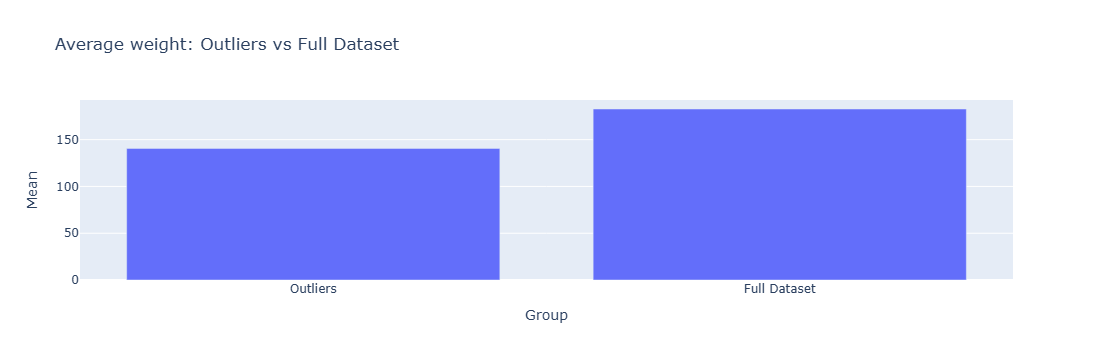

In [25]:
#Question 7c: Plot these comparions. You can choose the chart that you think will be more appropriate for visualization. (2 point)

# I used bar charts to compare the average values of the outliers to the full dataset.

variables = ['days_used', 'internal_memory', 'weight']

for variable in variables:
    comparison = pd.DataFrame({
        'Group': ['Outliers', 'Full Dataset'],
        'Mean': [outlier_df[variable].mean(), df[variable].mean()]
    })

    fig = px.bar(
        comparison,
        x='Group',
        y='Mean',
        title=f'Average {variable}: Outliers vs Full Dataset'
    )

    fig.show()
